# Data Preprocessing

In [1]:
pip install -U pymoo --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 7.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.1/249.1 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.1/77.1 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 7.4 MB/s eta 0:00:00


In [2]:
pip install ucimlrepo --quiet

In [3]:
pip install fairlearn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.0/240.0 kB 3.7 MB/s eta 0:00:00


In [4]:
pip install fairlearn matplotlib --quiet

In [5]:
pip install EMP-PY --quiet

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import xgboost as xgb
from xgboost import XGBClassifier

pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', None)
warnings.filterwarnings("ignore")

## data import

In [7]:
from ucimlrepo import fetch_ucirepo

# import (https://archive.ics.uci.edu/dataset/28/japanese+credit+screening)
japanese_credit_screening = fetch_ucirepo(id=28)

# data (as pandas dataframes)
X = japanese_credit_screening.data.features
y = japanese_credit_screening.data.targets

# sample 50% of data (for performance)
# X = X.sample(frac=0.5)
# y = y.iloc[X.index]

print(X.shape)
print(y.shape)



# convert target var to binary
y = y.replace({"-": 0, "+": 1}) # + : granted credit, -: not granted credit

print(X.shape)

X.head()

(690, 15)
(690, 1)
(690, 15)


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,00202,0
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,00043,560
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,00280,824
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,00100,3
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,00120,0


In [8]:
# print out default rate
print(y.value_counts(normalize=True))

A16
0      0.555072
1      0.444928
Name: proportion, dtype: float64


## FE

In [9]:
### Frequency Encoding ###

cat_vars = ["A1", "A4", "A5", "A6", "A7", "A9", "A10", "A11", "A12", "A13"]

# categorical_cols = X.select_dtypes(include=['object', 'category'])
# print(categorical_cols.head())
# X['A2'] = X['A2'].astype(float)

for col in cat_vars:
  freq_encoding = X[col].value_counts().to_dict()
  X[col] = X[col].map(freq_encoding) # replace original col

# convert all to numeric
X = X.apply(pd.to_numeric, errors='coerce')

# fill NAs
X.fillna(X.mean(), inplace=True)

X.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15
0,468,30.83,0.000,519,519,64,399,1.25,361,295,71,374,625,202.0,0
1,210,58.67,4.460,519,519,78,138,3.04,361,295,23,374,625,43.0,560
2,210,24.50,0.500,519,519,78,138,1.50,361,395,395,374,625,280.0,824
3,468,27.83,1.540,519,519,64,399,3.75,361,295,18,316,625,100.0,3
4,468,20.17,5.625,519,519,64,399,1.71,361,395,395,374,57,120.0,0


In [10]:
# encode categorical vars (instead of FE) --> many feats
# X = pd.get_dummies(X)

# X.head()

## train-test split

In [11]:
from sklearn.model_selection import train_test_split

# train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(X_train.shape, y_train.shape)

(483, 15) (483, 1)


# Funcs & Result Arrays

## grid search

In [12]:
# %%time
# import xgboost as xgb
# from xgboost import XGBClassifier
# from sklearn.model_selection import GridSearchCV
# from sklearn.metrics import accuracy_score, make_scorer
# from EMP.metrics import empCreditScoring

# ### GRID SEARCH ###

# # Step 1 #
# clf = XGBClassifier().fit(X_train, y_train)
# y_pred_proba = clf.predict_proba(X_test)[:, 1]

# # Step 2: Define the XGBoost model
# model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')

# # Step 3: Define the parameter grid
# param_grid = {
#     'n_estimators': [50, 100, 200],  # Number of trees
#     'learning_rate': [0.01, 0.1, 0.2],  # Step size shrinkage
#     'max_depth': [3, 4, 5],  # Maximum tree depth
#     'subsample': [0.8, 1.0],  # Subsample ratio of training instances
#     'colsample_bytree': [0.8, 1.0],  # Subsample ratio of columns
#     'gamma': [0, 1, 5],  # Minimum loss reduction
# }

# scores = y_pred_proba
# classes = y_test.values
# emp_score = empCreditScoring(scores, classes, rounding=3)[0]

# emp_scorer = make_scorer(emp_score, needs_proba=True, greater_is_better=True)

# # Step 4: Define GridSearchCV
# grid_search = GridSearchCV(
#     estimator=model,
#     param_grid=param_grid,
#     scoring='accuracy',
#     # scoring=emp_scorer,
#     cv=5,  # 5-fold cross-validation
#     verbose=1,
#     n_jobs=-1
# )

# # Step 5: Fit the model
# grid_search.fit(X_train, y_train)

# # Step 6: Evaluate the best model
# best_model = grid_search.best_estimator_
# y_pred = best_model.predict(X_test)
# accuracy = accuracy_score(y_test, y_pred)

# # XGB Best Parameters: {'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50, 'subsample': 0.8}
# print(f"Best Parameters: {grid_search.best_params_}")
# print(f"Test Accuracy: {accuracy:.4f}")

In [13]:
# %%time

# from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import GridSearchCV

# ### RF Grid Search ###
# param_grid = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [None, 10, 20, 30],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4]
# }

# grid_search = GridSearchCV(estimator=RandomForestClassifier(),
#                            param_grid=param_grid,
#                            cv=5,  # Number of cross-validation folds
#                            scoring='accuracy',  # Metric to optimize
#                            verbose=2,  # Print progress
#                            n_jobs=-1)  # Use all available cores


# grid_search.fit(X_train, y_train)

# print("Best Parameters:", grid_search.best_params_) # [max_depth= 10, min_samples_leaf= 1, min_samples_split= 5, n_estimators= 100]
# print("Best Score:", grid_search.best_score_)

# rf_params = grid_search.best_params_
# # rf_params_list = [max_depth= 10, min_samples_leaf= 1, min_samples_split= 5, n_estimators= 100]

# rf_params

In [14]:
# rf_params_list = [max_depth= 10, min_samples_leaf= 1, min_samples_split= 5, n_estimators= 100]

# rf_params_list

## EMP

In [15]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression
from EMP.metrics import empCreditScoring

### EMP func ###
def emp_func(no_of_features, direction="forward"):
  # FS
  fs = SequentialFeatureSelector(LogisticRegression(),
                                 n_features_to_select=no_of_features,
                                 direction=direction)
  fs.fit(X_train, y_train)
  X_train_new = fs.transform(X_train)
  X_test_new = fs.transform(X_test)

  # print("Features selected: ", fs.get_feature_names_out())

  # train classification model with selected features
  clf = XGBClassifier(colsample_bytree= 1.0,
                      gamma= 0,
                      learning_rate= 0.1,
                      max_depth= 5,
                      n_estimators= 50,
                      subsample= 0.8).fit(X_train_new, y_train) # params based on acc

  scores = clf.predict_proba(X_test_new)[:, 1] # y_pred_proba
  classes = y_test.values

  emp_score = empCreditScoring(scores, classes, rounding=3) # Will print and return output with k decimal points

  print("number of features: ", no_of_features, ", EMP: ", emp_score[0])

  return emp_score[0]

In [16]:
emp_func(3)

number of features:  3 , EMP:  0.104


np.float64(0.104)

In [17]:
%%time

# create results dict
results_emp = {}

for i in range(1, len(X.columns)):
  results_emp[i] = emp_func(i, direction="backward") # , direction="backward"

# print(results_emp)

# converto to pd Series
df_res_emp = pd.Series(results_emp)

df_res_emp

number of features:  1 , EMP:  0.104
number of features:  2 , EMP:  0.102
number of features:  3 , EMP:  0.102
number of features:  4 , EMP:  0.102
number of features:  5 , EMP:  0.103
number of features:  6 , EMP:  0.103
number of features:  7 , EMP:  0.104
number of features:  8 , EMP:  0.105
number of features:  9 , EMP:  0.108
number of features:  10 , EMP:  0.108
number of features:  11 , EMP:  0.107
number of features:  12 , EMP:  0.109
number of features:  13 , EMP:  0.109
number of features:  14 , EMP:  0.109
CPU times: user 5min, sys: 1.02 s, total: 5min 1s
Wall time: 3min 1s


,0
1,0.104
2,0.102
3,0.102
4,0.102
5,0.103
6,0.103
7,0.104
8,0.105
9,0.108
10,0.108


## Fairness

In [18]:
from fairlearn.metrics import MetricFrame
from fairlearn.metrics import selection_rate
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

### Fairness Function ###
# https://fairlearn.org/v0.10/quickstart.html

def fair_func(no_of_features): # !!! fix fairness calc

  # FS: SFS
  fs = SequentialFeatureSelector(LogisticRegression(), n_features_to_select=no_of_features)
  fs.fit(X_train, y_train)

  # create new X_train and X_test based on selected features
  X_train_new = fs.transform(X_train)
  X_test_new = fs.transform(X_test)
  # print("Features selected: ", fs.get_feature_names_out())

  # classification
  #clf = XGBClassifier(colsample_bytree= 1.0,
  #                    gamma= 0,
  #                    learning_rate= 0.1,
  #                max_depth= 5,
  #                    n_estimators= 50,
  #                    subsample= 0.8)
  # max_depth= 10, min_samples_leaf= 1, min_samples_split= 5, n_estimators= 100
  clf = RandomForestClassifier(max_depth= 10, min_samples_leaf= 1, min_samples_split= 5, n_estimators= 100) # *rf_params_list
  clf.fit(X_train, y_train)
  y_pred = clf.predict(X_test)

  mf = MetricFrame(metrics=accuracy_score, # [selection_rate, accuracy_score]
                  y_true=y_test,
                  y_pred=y_pred,
                  sensitive_features=X_test["A6"] # A6 seems to be some kind of grouping # A1? # can be categorical
                  )

  fair_score = mf.overall.round(3)
  # fair_score_group = mf.by_group

  # print("number of features: ", no_of_features, ", fairness: ", fair_score)

  return fair_score

fair_func(3)

np.float64(0.85)

In [19]:
%%time

# create results dict
results_fair = {}

for i in range(1, len(X.columns)):
  results_fair[i] = fair_func(i)

# print(results_emp)

# converto to pd Series
df_res_fair = pd.Series(results_fair)

df_res_fair

CPU times: user 3min 29s, sys: 684 ms, total: 3min 30s
Wall time: 2min 1s


,0
1,0.855
2,0.855
3,0.845
4,0.865
5,0.865
6,0.860
7,0.845
8,0.850
9,0.870
10,0.860


# Optimization

## 1-Obj

In [20]:
# max value from results dict/list
emp_scores = df_res_emp.tolist()

max_emp = max(emp_scores)
max_emp_ind = emp_scores.index(max(emp_scores)) +1
max_emp_perc = round(max_emp_ind/(len(emp_scores)+1), 2)*100

print("maximum EMP: ", max_emp, ", ", max_emp_ind, "/", len(emp_scores)+1,
      " features used(", max_emp_perc,"%)")
# print("AUC w/ max.EMP feature count:", results_auc[max_emp_ind])
# print("Acc w/ max.EMP feature count:", results_acc[max_emp_ind])
print("fairness w/ max.EMP feature count:", results_fair[max_emp_ind])
print("CPU time: ", )
%time emp_func(max_emp_ind) # %timeit

maximum EMP:  0.109 ,  12 / 15  features used( 80.0 %)
fairness w/ max.EMP feature count: 0.87
CPU time: 
number of features:  12 , EMP:  0.106
CPU times: user 22.7 s, sys: 82.5 ms, total: 22.7 s
Wall time: 13 s


np.float64(0.106)

### Scatter

Text(0, 0.5, 'EMP')

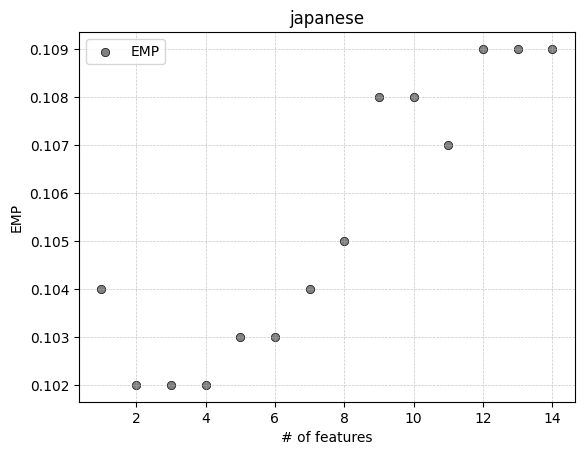

In [21]:
# TODO: format maximum value (solution)
# TODO: add data labels for max
# TODO: add AUC and/or Acc on plot

# Scatterplot EMP - # Features
sns.scatterplot(x=range(1, len(X_train.columns)), y=df_res_emp, label="EMP", color = "grey", edgecolor="black")

# add second axis to plot
# ax2 = plt.twinx()
# sns.scatterplot(x=range(1, len(X_train.columns)), y=df_res_auc, label="AUC", color="orange", ax=ax2, alpha=0.5, s=20) # size=
# sns.scatterplot(x=range(1, len(X_train.columns)), y=df_res_acc, label="Acc", color="green", ax=ax2, alpha=0.2)



plt.grid(True, which="both", axis="both", linestyle='--', linewidth=0.5, alpha=0.7)
plt.legend() #loc="upper left"
plt.title('japanese')
plt.xlabel('# of features')
plt.ylabel('EMP')

In [22]:
# ### SBS ####
# emp_scores = df_res_emp_sbs.tolist()

# max_emp = max(emp_scores) # emp_scores, df_res_emp, results_emp
# max_emp_ind = emp_scores.index(max(emp_scores))+1
# max_emp_perc = round(max_emp_ind/len(emp_scores), 2)*100

# print("maximum EMP: ", max_emp, ", ", max_emp_ind, "/", len(emp_scores),
#       " features used(", max_emp_perc,"%)")

## 2-Obj

In [23]:
from pymoo.problems.functional import FunctionalProblem

# problem def & opti, plot
max_n_features = max(results_emp.keys())

def restrain_integer_sampling(n_features):
  if n_features > max_n_features:
    return max_n_features
  elif n_features < 1:
    return 1
  else:
    return n_features

def calculate_emp(n_features):
  return -1*results_emp[n_features]

def minimize_n_features(n_features):
  return n_features

def maximize_fairness(n_features):
  return -1*results_fair[n_features]

In [24]:
# With IntegerRandomSampling
objs = [
    lambda x: calculate_emp(restrain_integer_sampling(abs(int(x[0])))),
    lambda x: minimize_n_features(restrain_integer_sampling(abs(int(x[0])))),
    # lambda x: maximize_fairness(restrain_integer_sampling(abs(int(x[0]))))
]

n_var = 1

problem = FunctionalProblem(
    n_var,
    objs,
    # constr_ieq=constr_ieq,
    xl=np.array([1]),
    xu=np.array([5]),
    vtype=[int, int]
)

N_features_to_try = [3]  # Integer Random Sampling

F = problem.evaluate(np.array(N_features_to_try).reshape(len(N_features_to_try), 1)) # convert from (1) to (1, 1)

print(f"F: {F}\n")

F: [[-0.102  3.   ]]



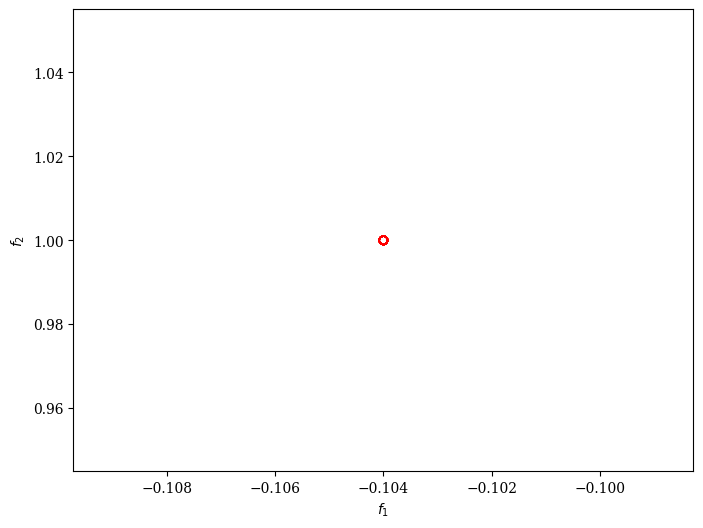

In [25]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.sampling.rnd import IntegerRandomSampling
from pymoo.optimize import minimize
from pymoo.visualization.scatter import Scatter
from pymoo.operators.crossover.sbx import SimulatedBinaryCrossover
from pymoo.operators.mutation.pm import PolynomialMutation

algorithm = NSGA2(
    pop_size=100,
    sampling = IntegerRandomSampling(),
    crossover=SimulatedBinaryCrossover(eta=15, prob=0.9),
    mutation=PolynomialMutation(),
    eliminate_duplicates=True
  )

res = minimize(problem,
               algorithm,
               ('n_gen', 100),
               seed=1,
               verbose=False)
# Plot
plot = Scatter()
# plot.add(problem.pareto_front(), plot_type="line", color="black", alpha=0.7)
plot.add(res.F, facecolor="none", edgecolor="red")

# plt.gca().invert_xaxis()
# plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
# plt.title("Japanese")
# plt.gca().invert_xaxis()

plot.show()

In [26]:
# calculate number of features for best solution
emp_list = [abs(i) for i, j in res.F]
fs_counts = [j for i, j in res.F]

max_emp = max(emp_list)
max_fs_counts = int(max(fs_counts))
# print("Number of features:", max_fs_counts)

# Output
print("2-Obj Opti Results: ", "", sep="\n")
print("max EMP:", max_emp)
# print("AUC:", auc_func(max_fs_counts))
# print("Acc:", acc_func(max_fs_counts))
print("Fairness score:", fair_func(max_fs_counts))
# print("CPU time: ", round(res.exec_time, 3))
%time emp_func(max_fs_counts)

2-Obj Opti Results: 

max EMP: 0.104
Fairness score: 0.86
number of features:  1 , EMP:  0.104
CPU times: user 1.62 s, sys: 4.99 ms, total: 1.62 s
Wall time: 852 ms


np.float64(0.104)

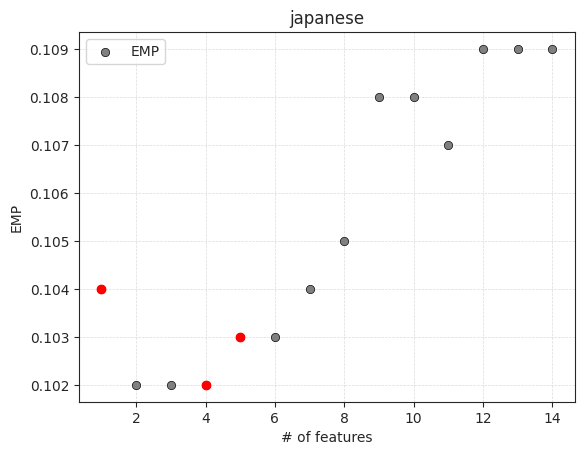

In [38]:
### plot w/SO scatter ###

def plot_solution(X_train, df_res_emp, highlight_indices=None):
  """highilight solutions"""
  # Scatterplot EMP - # Features
  sns.scatterplot(x=range(1, len(X_train.columns)), y=df_res_emp, label="EMP", color="grey", edgecolor="black")

  plt.grid(True, which="both", axis="both", linestyle='--', linewidth=0.5, alpha=0.7)
  plt.legend() #loc="upper left"
  plt.title('japanese')
  plt.xlabel('# of features')
  plt.ylabel('EMP')

  if highlight_indices is not None:
    # Add a single point with a different color
    # plt.scatter(highlight_indices, X_train.iloc[highlight_indices], color='red', label='Special Point')
    plt.scatter(highlight_indices, df_res_emp[highlight_indices], color='red', label='Special Point')
    pass # TODO

plot_solution(X_train, df_res_emp, np.unique(res.F[:, 1]))
# plot_solution(X_train, df_res_emp)

In [28]:
%%time
emp_func(max_fs_counts)

number of features:  1 , EMP:  0.104
CPU times: user 1.62 s, sys: 5.96 ms, total: 1.63 s
Wall time: 854 ms


np.float64(0.104)

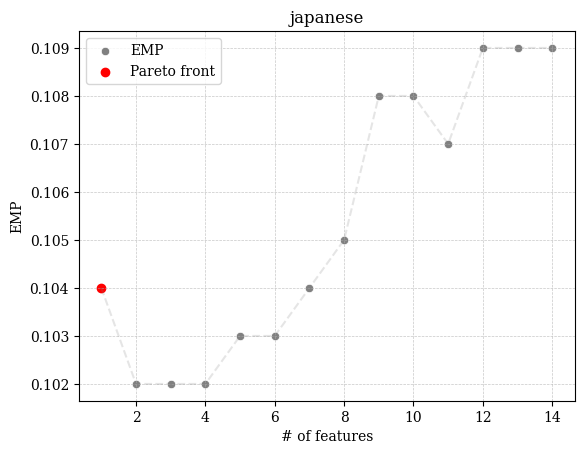

In [29]:
### plot w/SO scatter ###

def plot_solution_2d(x, y, parameters={}, highlight_indices=None):
  """highilight solutions"""
  # Scatterplot EMP - # Features
  sns.scatterplot(x=x, y=y, label=parameters.get('label'), color='grey')
  plt.plot(x, y, linestyle='--', color='grey', alpha=0.2)  # Add connecting line


  plt.grid(True, which="both", axis="both", linestyle='--', linewidth=0.5, alpha=0.7)

  plt.title(parameters.get('title'))
  plt.xlabel(parameters.get('x_label'))
  plt.ylabel(parameters.get('y_label'))

  if highlight_indices is not None:
    # Add a single point with a different color
    # plt.scatter(highlight_indices, X_train.iloc[highlight_indices], color='red', label='Special Point')
    plt.scatter(highlight_indices, df_res_emp[highlight_indices], color='red', label='Pareto front')

  plt.legend() #loc="upper left"

parameters = {
    'label': "EMP",
    'title': 'japanese',
    'x_label': '# of features',
    'y_label': 'EMP',
}
plot_solution_2d(list(range(1, len(X_train.columns))), df_res_emp, parameters, np.unique(res.F[:, 1]))
# plot_solution(X_train, df_res_emp)

## 3-Obj

In [30]:
# With IntegerRandomSampling
objs = [
    lambda x: calculate_emp(restrain_integer_sampling(abs(int(x[0])))),
    lambda x: minimize_n_features(restrain_integer_sampling(abs(int(x[0])))),
    lambda x: maximize_fairness(restrain_integer_sampling(abs(int(x[0]))))
]

n_var = 1

problem = FunctionalProblem(
    n_var,
    objs,
    xl=np.array([1]),
    xu=np.array([5]),
    vtype=[int, int]
)

N_features_to_try = [3]  # Integer Random Sampling

F = problem.evaluate(np.array(N_features_to_try).reshape(len(N_features_to_try), 1)) # convert from (1) to (1, 1)

print(f"F: {F}\n")

F: [[-0.102  3.    -0.845]]



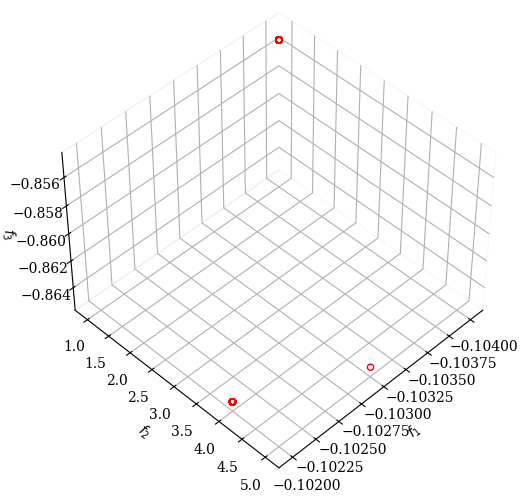

In [31]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.sampling.rnd import IntegerRandomSampling
from pymoo.optimize import minimize
from pymoo.visualization.scatter import Scatter
from pymoo.operators.crossover.sbx import SimulatedBinaryCrossover
from pymoo.operators.mutation.pm import PolynomialMutation

algorithm = NSGA2(
    pop_size=100,
    sampling = IntegerRandomSampling(),
    crossover=SimulatedBinaryCrossover(eta=15, prob=0.9),
    mutation=PolynomialMutation(),
    eliminate_duplicates=True
  )

res = minimize(problem,
               algorithm,
               ('n_gen', 100),
               seed=1,
               verbose=False)
# Plot
plot = Scatter()

plot.add(problem.pareto_front(), plot_type="line", color="black", alpha=0.7)
plot.add(res.F, facecolor="none", edgecolor="red")

# plt.grid(True)
# plt.title("3-Obj Opti")
# plt.gca().invert_xaxis()


plot.show()

In [32]:
# calculate number of features for best solution
emp_list = [abs(i) for i, j, k in res.F]
fs_counts = [j for i, j, k in res.F]
fair_scores = [k for i, j, k in res.F]

max_emp = max(emp_list)
max_fs_counts = int(max(fs_counts))
# print("Number of features:", max_fs_counts)

### OUTPUT ###
print("3-Obj Opti Results: ", "", sep="\n")
print("max EMP:", max_emp)
# print("AUC:", auc_func(max_fs_counts))
# print("Acc:", acc_func(max_fs_counts))
# print("CPU time: ", round(res.exec_time, 3))
print("Fairness score:", fair_func(max_fs_counts))

3-Obj Opti Results: 

max EMP: 0.104
Fairness score: 0.855


In [33]:
%%time
emp_func(max_fs_counts)

number of features:  5 , EMP:  0.103
CPU times: user 9.67 s, sys: 32.9 ms, total: 9.71 s
Wall time: 5.19 s


np.float64(0.103)

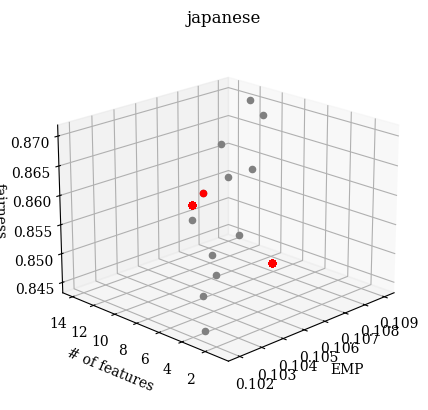

In [34]:
def plot_solution_3d(x, y, z, point_labels, parameters={}, highlight_indices=None):
  # Create a figure and a 3D subplot
  fig = plt.figure()
  ax = fig.add_subplot(111, projection='3d')

  # Create the 3D scatter plot using Seaborn's color palette
  # darkgrid, whitegrid, dark, white, ticks
  sns.set_style("ticks") # Set Seaborn style
  # ax.scatter(x, y, z, c=z, cmap=sns.color_palette("viridis", as_cmap=True))  # Color points by z-value

  grey_idx = point_labels == "2-obj"
  red_idx = point_labels == "3-obj"
  ax.scatter(x[grey_idx], y[grey_idx], z[grey_idx], c="grey", depthshade=False)  # Color points by z-value
  ax.scatter(x[red_idx], y[red_idx], z[red_idx], c="red", depthshade=False)  # Color points by z-value
  # ax.view_init(elev=10, azim=300)
  ax.view_init(elev=20, azim=225)  # Example angles


  # Set labels and title
  ax.set_xlabel(parameters.get("x_label"))
  ax.set_ylabel(parameters.get("y_label"))
  ax.set_zlabel(parameters.get("z_label"))
  ax.set_title(parameters.get("title"))

  plt.show()


# Convert results to 3D DataFrame -- 3-Obj
res_f_df = pd.DataFrame(res.F, columns=["f1", "f2", "f3"])
res_f_df = res_f_df.abs()
res_f_df["label"] = "3-obj"


# Convert the Series to 3D DataFrame - 2-Obj
df_res_emp_for_3d = pd.DataFrame(df_res_emp, columns=['f1'])  # Series to DataFrame
df_res_emp_for_3d["f2"] = range(1, len(df_res_emp)+1) # Add 'f2' column
df_res_emp_for_3d["f3"] = df_res_fair # Add 'f3' column
df_res_emp_for_3d["label"] = "2-obj"
df_res_emp_for_3d = df_res_emp_for_3d[["f1", "f2", "f3", "label"]]

merged_results = pd.concat([res_f_df, df_res_emp_for_3d], axis=0)

# res_f_df_1st_dim = res_f_df.iloc[:, 0]
# res_f_df_2nd_dim = res_f_df.iloc[:, 1]
# res_f_df_3rd_dim = res_f_df.iloc[:, 2]

df_1st_dim = merged_results.iloc[:, 0]
df_2nd_dim = merged_results.iloc[:, 1]
df_3rd_dim = merged_results.iloc[:, 2]
df_point_labels = merged_results.iloc[:, 3]

plot_solution_3d(
    x=df_1st_dim,
    y=df_2nd_dim,
    z=df_3rd_dim,
    point_labels=df_point_labels,
    parameters={'label': "EMP", 'title': "japanese", 'x_label': 'EMP', 'y_label': '# of features', 'z_label': 'fairness'}
)

## Full model

In [35]:
%%time

# CPU time
emp_func(len(X.columns)-1)


number of features:  14 , EMP:  0.105
CPU times: user 24.4 s, sys: 73.5 ms, total: 24.5 s
Wall time: 13.9 s


np.float64(0.105)

In [36]:
%%time

print("EMP with all features:", results_emp[max(results_emp.keys())])
# print("AUC with all features:", results_auc[max(results_emp.keys())])
# print("Acc with all features: ", results_acc[max(results_acc.keys())])
print("# features used: ", len(X_train.columns))
print("Fairness with all feats:", results_fair[max(results_fair.keys())])
print("CPU time:")
%time emp_func(len(X.columns)-1)

EMP with all features: 0.109
# features used:  15
Fairness with all feats: 0.855
CPU time:
number of features:  14 , EMP:  0.105
CPU times: user 28.8 s, sys: 105 ms, total: 28.9 s
Wall time: 21.8 s
CPU times: user 28.8 s, sys: 105 ms, total: 28.9 s
Wall time: 21.8 s


np.float64(0.105)

In [37]:
X_train.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15
178,210,18.42,9.250,519,519,78,399,1.210,361,295,15,374,625,60.0,540
265,468,17.08,0.085,163,163,137,399,0.040,329,395,395,374,625,140.0,722
352,468,22.50,11.500,163,163,38,399,1.500,329,395,395,316,625,0.0,4000
529,468,43.25,25.210,519,519,78,138,0.210,361,295,71,374,625,760.0,90
409,468,17.08,0.250,519,519,78,399,0.335,329,295,15,374,625,160.0,8
